# Final Experiments Part 4: Domain-Specific Fine-Tuning on SciFact
**CS 593 NLP Final Project — Purdue University, Spring 2026**

Authors: Varun Chundru, Debasmita Biswas

This notebook directly addresses the project title: *Domain-Specific* Hallucination
Detection. Update 2 demonstrated that the HaluEval-trained DeBERTa generalizes poorly
to the biomedical SciFact benchmark (F1 = 0.50, essentially predicting "hallucinated"
for everything). That is the motivation, not the conclusion.

Here we train **three domain-specific detectors on SciFact** and compare them directly
against the zero-shot transfer baseline from Update 2:

| Config | Base model | Training data |
|---|---|---|
| **Baseline** (from Update 2) | HaluEval-trained DeBERTa | — (zero-shot transfer) |
| **A: DeBERTa-SciFact** | `microsoft/deberta-v3-base` | SciFact train |
| **B: PubMedBERT-SciFact** | `microsoft/BiomedNLP-PubMedBERT-base-uncased-abstract` | SciFact train |
| **C: HaluEval→SciFact** | HaluEval-trained DeBERTa | SciFact train (continued) |

Config A isolates the effect of domain-matched *training*. Config B adds domain-matched
*pre-training*. Config C tests whether HaluEval pre-training gives a useful
initialization for scientific claims (transfer learning).

**Environment:** Kaggle Notebook with GPU (T4x2). SciFact is small (~700 train claims)
so each run takes ~5 min.

## 1. Setup

In [2]:
import os
import json
import io
import tarfile
import requests
import time
import numpy as np
import pandas as pd
import torch
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    DataCollatorWithPadding,
    Trainer,
    TrainingArguments,
)
from datasets import Dataset, DatasetDict
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, roc_auc_score
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"GPU count: {torch.cuda.device_count()}")

Device: cuda
GPU: Tesla T4
GPU count: 2


## 2. Load SciFact (same source as notebook 02)

In [3]:
print("Loading SciFact from source...")
url = "https://scifact.s3-us-west-2.amazonaws.com/release/latest/data.tar.gz"
response = requests.get(url)
tar = tarfile.open(fileobj=io.BytesIO(response.content), mode="r:gz")

corpus_list = [json.loads(line) for line in tar.extractfile("data/corpus.jsonl")]
claims = [json.loads(line) for line in tar.extractfile("data/claims_train.jsonl")]
claims += [json.loads(line) for line in tar.extractfile("data/claims_dev.jsonl")]

print(f"Corpus: {len(corpus_list)} abstracts")
print(f"Claims: {len(claims)} (train+dev)")

# Build doc_id → corpus entry map
doc_map = {}
for doc in corpus_list:
    doc_id = doc['doc_id']
    title = doc.get('title', '')
    abstract = doc.get('abstract', [])
    if isinstance(abstract, list):
        abstract_sents = abstract
        abstract_text = " ".join(abstract)
    else:
        abstract_sents = [str(abstract)]
        abstract_text = str(abstract)
    doc_map[doc_id] = {
        'title': title,
        'abstract_sents': abstract_sents,
        'abstract_text': abstract_text,
    }

Loading SciFact from source...
Corpus: 5183 abstracts
Claims: 1109 (train+dev)


## 3. Build labeled (claim, evidence) pairs

In [4]:
# SciFact label structure:
#   claim['evidence'] = { "doc_id_str": [{"label": "SUPPORT"/"CONTRADICT",
#                                         "sentences": [sent_idx, ...]}, ...], ... }
# Empty dict = NOT ENOUGH INFO (we drop these — can't tell binary).
#
# Strategy: use GOLD evidence sentences from the cited abstract as the evidence string.
# This is cleaner than retrieval for fine-tuning. We'll evaluate on the same gold
# evidence so that all three models are compared on the same inputs.

examples = []
for claim in claims:
    evidence = claim.get('evidence', {})
    if not evidence:
        continue  # skip NOT ENOUGH INFO

    # Find the first labeled evidence block
    chosen_label = None
    chosen_doc_id = None
    chosen_sents = None
    for doc_id_str, ev_list in evidence.items():
        for ev in ev_list:
            if 'label' in ev:
                chosen_label = ev['label']
                chosen_doc_id = int(doc_id_str)
                chosen_sents = ev.get('sentences', [])
                break
        if chosen_label:
            break

    if chosen_label is None or chosen_doc_id not in doc_map:
        continue

    # Build evidence text from gold sentences (or full abstract as fallback)
    doc = doc_map[chosen_doc_id]
    if chosen_sents:
        try:
            evidence_text = " ".join(doc['abstract_sents'][i] for i in chosen_sents)
        except IndexError:
            evidence_text = doc['abstract_text']
    else:
        evidence_text = doc['abstract_text']

    # Label: 1 = hallucinated (CONTRADICT), 0 = factual (SUPPORT)
    # Map SciFact's terminology to our binary scheme
    if chosen_label in ['CONTRADICT', 'REFUTE', 'REFUTES']:
        binary_label = 1
    elif chosen_label in ['SUPPORT', 'SUPPORTS']:
        binary_label = 0
    else:
        continue

    text = f"Claim: {claim['claim']}\nEvidence: {evidence_text[:1500]}"
    examples.append({'text': text, 'label': binary_label, 'claim_id': claim['id']})

print(f"Built {len(examples)} labeled (claim, evidence) examples")
n_pos = sum(1 for e in examples if e['label'] == 1)
n_neg = sum(1 for e in examples if e['label'] == 0)
print(f"  Hallucinated (CONTRADICT): {n_pos}  ({n_pos/len(examples)*100:.1f}%)")
print(f"  Factual (SUPPORT):         {n_neg}  ({n_neg/len(examples)*100:.1f}%)")

print("\nExample:")
print(f"  Label: {examples[0]['label']}")
print(f"  Text (first 300 chars): {examples[0]['text'][:300]}")

Built 693 labeled (claim, evidence) examples
  Hallucinated (CONTRADICT): 237  (34.2%)
  Factual (SUPPORT):         456  (65.8%)

Example:
  Label: 1
  Text (first 300 chars): Claim: 1 in 5 million in UK have abnormal PrP positivity.
Evidence: RESULTS Of the 32,441 appendix samples 16 were positive for abnormal PrP, indicating an overall prevalence of 493 per million population (95% confidence interval 282 to 801 per million).


## 4. Train/val/test split (stratified, seed=42)

In [5]:
# Stratified 70/15/15 split
rng = np.random.RandomState(42)

pos_examples = [e for e in examples if e['label'] == 1]
neg_examples = [e for e in examples if e['label'] == 0]
rng.shuffle(pos_examples)
rng.shuffle(neg_examples)


def split_70_15_15(items):
    n = len(items)
    n_train = int(n * 0.70)
    n_val = int(n * 0.15)
    return items[:n_train], items[n_train:n_train+n_val], items[n_train+n_val:]


train_pos, val_pos, test_pos = split_70_15_15(pos_examples)
train_neg, val_neg, test_neg = split_70_15_15(neg_examples)

train_examples = train_pos + train_neg
val_examples = val_pos + val_neg
test_examples = test_pos + test_neg

rng.shuffle(train_examples)
rng.shuffle(val_examples)
rng.shuffle(test_examples)

print(f"Split sizes:")
print(f"  Train: {len(train_examples)}  (pos={sum(e['label'] for e in train_examples)})")
print(f"  Val:   {len(val_examples)}  (pos={sum(e['label'] for e in val_examples)})")
print(f"  Test:  {len(test_examples)}  (pos={sum(e['label'] for e in test_examples)})")

# Save splits for reproducibility
pd.DataFrame(test_examples).to_csv("scifact_test_split.csv", index=False)
print("Saved scifact_test_split.csv")

Split sizes:
  Train: 484  (pos=165)
  Val:   103  (pos=35)
  Test:  106  (pos=37)
Saved scifact_test_split.csv


In [6]:
# Convert to HuggingFace Dataset
def to_hf(items):
    return Dataset.from_dict({
        'text': [e['text'] for e in items],
        'label': [e['label'] for e in items],
    })

scifact_splits = DatasetDict({
    'train': to_hf(train_examples),
    'validation': to_hf(val_examples),
    'test': to_hf(test_examples),
})

## 5. Shared evaluation helper

In [7]:
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)
    probs = torch.softmax(torch.tensor(logits), dim=-1)[:, 1].numpy()
    acc = accuracy_score(labels, preds)
    p, r, f1, _ = precision_recall_fscore_support(labels, preds, average="binary", zero_division=0)
    try:
        auroc = roc_auc_score(labels, probs)
    except ValueError:
        auroc = 0.0
    return {'accuracy': acc, 'precision': p, 'recall': r, 'f1': f1, 'auroc': auroc}


def tokenize_dataset(tokenizer, splits):
    def tok_fn(ex):
        return tokenizer(ex['text'], truncation=True, max_length=512, padding=False)
    tokenized = splits.map(tok_fn, batched=True, remove_columns=['text'])
    tokenized = tokenized.rename_column('label', 'labels')
    tokenized.set_format('torch', columns=['input_ids', 'attention_mask', 'labels'])
    return tokenized


# def train_and_eval(base_model_name, config_name, splits, epochs=5, lr=2e-5, load_path=None):
#     """
#     Train a classifier on SciFact and evaluate on test.

#     Args:
#         base_model_name: HuggingFace repo used for tokenizer and (if load_path is None) weights.
#         config_name: Label for reporting.
#         splits: DatasetDict with train/validation/test.
#         epochs, lr: training hyperparameters.
#         load_path: If set, load classifier weights from this HF repo (used for the
#                    HaluEval-pretrained transfer config) while still tokenizing with
#                    base_model_name's tokenizer.
#     """
#     print(f"\n{'='*70}")
#     print(f"Training: {config_name}")
#     print(f"{'='*70}")

#     tokenizer = AutoTokenizer.from_pretrained(load_path if load_path else base_model_name)
#     tokenized = tokenize_dataset(tokenizer, splits)

#     model_source = load_path if load_path else base_model_name
#     print(f"Loading weights from: {model_source}")
#     model = AutoModelForSequenceClassification.from_pretrained(
#         model_source, num_labels=2,
#         ignore_mismatched_sizes=True,  # in case load_path has different head size
#     )
#     model = model.float().to(device)

#     args = TrainingArguments(
#         output_dir=f"./scifact_{config_name.replace(' ', '_').replace(':', '').replace('/', '_')}",
#         num_train_epochs=epochs,
#         per_device_train_batch_size=8,
#         per_device_eval_batch_size=16,
#         learning_rate=lr,
#         weight_decay=0.01,
#         logging_steps=50,
#         eval_strategy="epoch",
#         save_strategy="no",
#         fp16=False,
#         report_to="none",
#         seed=42,
#         load_best_model_at_end=False,
#     )

#     data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

#     trainer = Trainer(
#         model=model,
#         args=args,
#         train_dataset=tokenized['train'],
#         eval_dataset=tokenized['validation'],
#         processing_class=tokenizer,
#         data_collator=data_collator,
#         compute_metrics=compute_metrics,
#     )

#     start = time.time()
#     trainer.train()
#     train_time = time.time() - start

#     print(f"\nEvaluating on SciFact test set...")
#     test_metrics = trainer.evaluate(tokenized['test'])

#     # Collect raw predictions for per-example error analysis
#     preds_output = trainer.predict(tokenized['test'])
#     probs = torch.softmax(torch.tensor(preds_output.predictions), dim=-1)[:, 1].numpy()
#     preds = (probs > 0.5).astype(int)

#     result = {
#         'config': config_name,
#         'base_model': base_model_name,
#         'train_time_sec': train_time,
#         'accuracy': test_metrics['eval_accuracy'],
#         'precision': test_metrics['eval_precision'],
#         'recall': test_metrics['eval_recall'],
#         'f1': test_metrics['eval_f1'],
#         'auroc': test_metrics['eval_auroc'],
#         'test_probs': probs,
#         'test_preds': preds,
#     }

#     del model, trainer
#     torch.cuda.empty_cache()
#     return result



def train_and_eval(base_model_name, config_name, splits, epochs=15, lr=1e-5, load_path=None):
    print(f"\n{'='*70}")
    print(f"Training: {config_name}")
    print(f"{'='*70}")

    tokenizer = AutoTokenizer.from_pretrained(load_path if load_path else base_model_name)
    tokenized = tokenize_dataset(tokenizer, splits)

    model_source = load_path if load_path else base_model_name
    print(f"Loading weights from: {model_source}")
    model = AutoModelForSequenceClassification.from_pretrained(
        model_source, num_labels=2,
        ignore_mismatched_sizes=True,
    )
    model = model.float().to(device)

    # Compute class weights to handle imbalance
    train_labels = [ex['labels'].item() for ex in tokenized['train']]
    n_neg = train_labels.count(0)
    n_pos = train_labels.count(1)
    total = n_neg + n_pos
    # Weight inversely proportional to frequency
    weight_neg = total / (2 * n_neg)
    weight_pos = total / (2 * n_pos)
    class_weights = torch.tensor([weight_neg, weight_pos], dtype=torch.float).to(device)
    print(f"Class weights: neg={weight_neg:.3f}, pos={weight_pos:.3f}")

    # Custom trainer with weighted loss
    class WeightedTrainer(Trainer):
        def compute_loss(self, model, inputs, return_outputs=False, **kwargs):
            labels = inputs.pop("labels")
            outputs = model(**inputs)
            logits = outputs.logits
            loss_fn = torch.nn.CrossEntropyLoss(weight=class_weights)
            loss = loss_fn(logits, labels)
            return (loss, outputs) if return_outputs else loss

    args = TrainingArguments(
        output_dir=f"./scifact_{config_name}",
        num_train_epochs=epochs,
        per_device_train_batch_size=8,
        per_device_eval_batch_size=16,
        learning_rate=lr,
        weight_decay=0.01,
        warmup_ratio=0.1,
        logging_steps=50,
        eval_strategy="epoch",
        save_strategy="no",
        fp16=False,
        report_to="none",
        seed=42,
        load_best_model_at_end=False,
    )

    data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

    trainer = WeightedTrainer(
        model=model,
        args=args,
        train_dataset=tokenized['train'],
        eval_dataset=tokenized['validation'],
        processing_class=tokenizer,
        data_collator=data_collator,
        compute_metrics=compute_metrics,
    )

    start = time.time()
    trainer.train()
    train_time = time.time() - start

    print(f"\nEvaluating on SciFact test set...")
    test_metrics = trainer.evaluate(tokenized['test'])

    preds_output = trainer.predict(tokenized['test'])
    probs = torch.softmax(torch.tensor(preds_output.predictions), dim=-1)[:, 1].numpy()
    preds = (probs > 0.5).astype(int)

    result = {
        'config': config_name,
        'base_model': base_model_name,
        'train_time_sec': train_time,
        'accuracy': test_metrics['eval_accuracy'],
        'precision': test_metrics['eval_precision'],
        'recall': test_metrics['eval_recall'],
        'f1': test_metrics['eval_f1'],
        'auroc': test_metrics['eval_auroc'],
        'test_probs': probs,
        'test_preds': preds,
    }

    del model, trainer
    torch.cuda.empty_cache()
    return result

## 6. Config A: DeBERTa-v3-base fine-tuned on SciFact

In [8]:
result_A = train_and_eval(
    base_model_name="microsoft/deberta-v3-base",
    config_name="A_DeBERTa_SciFact",
    splits=scifact_splits,
    epochs=15,
    lr=1e-5,
)
print(f"\nConfig A Results: Acc={result_A['accuracy']:.4f}  F1={result_A['f1']:.4f}  AUROC={result_A['auroc']:.4f}")


Training: A_DeBERTa_SciFact


config.json:   0%|          | 0.00/579 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/52.0 [00:00<?, ?B/s]

spm.model:   0%|          | 0.00/2.46M [00:00<?, ?B/s]

Map:   0%|          | 0/484 [00:00<?, ? examples/s]

...

DebertaV2ForSequenceClassification LOAD REPORT from: microsoft/deberta-v3-base
Key                                     | Status     | 
----------------------------------------+------------+-
mask_predictions.LayerNorm.bias         | UNEXPECTED | 
mask_predictions.LayerNorm.weight       | UNEXPECTED | 
lm_predictions.lm_head.LayerNorm.weight | UNEXPECTED | 
lm_predictions.lm_head.LayerNorm.bias   | UNEXPECTED | 
lm_predictions.lm_head.bias             | UNEXPECTED | 
mask_predictions.classifier.weight      | UNEXPECTED | 
mask_predictions.dense.weight           | UNEXPECTED | 
mask_predictions.classifier.bias        | UNEXPECTED | 
lm_predictions.lm_head.dense.weight     | UNEXPECTED | 
lm_predictions.lm_head.dense.bias       | UNEXPECTED | 
mask_predictions.dense.bias             | UNEXPECTED | 
classifier.bias                         | MISSING    | 
classifier.weight                       | MISSING    | 
pooler.dense.bias                       | MISSING    | 
pooler.dense.weight      

Class weights: neg=0.759, pos=1.467


Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1,Auroc
1,No log,0.692242,0.407767,0.355556,0.914286,0.512000,0.547899
2,0.699868,0.697629,0.640777,0.000000,0.000000,0.000000,0.530672
3,0.699868,0.699644,0.621359,0.250000,0.057143,0.093023,0.548319
4,0.688576,0.701778,0.601942,0.425000,0.485714,0.453333,0.568487
5,0.679277,0.719707,0.543689,0.384615,0.571429,0.459770,0.522269
6,0.679277,0.739001,0.504854,0.318182,0.400000,0.354430,0.506723
7,0.646099,0.858874,0.563107,0.307692,0.228571,0.262295,0.513025
8,0.646099,0.772070,0.466019,0.352941,0.685714,0.466019,0.511345
9,0.621853,0.963996,0.621359,0.250000,0.057143,0.093023,0.454202
10,0.600768,0.924399,0.524272,0.181818,0.114286,0.140351,0.492437



Evaluating on SciFact test set...



Config A Results: Acc=0.5377  F1=0.2687  AUROC=0.5699


## 7. Config B: PubMedBERT fine-tuned on SciFact

In [9]:
result_B = train_and_eval(
    base_model_name="microsoft/BiomedNLP-PubMedBERT-base-uncased-abstract",
    config_name="B_PubMedBERT_SciFact",
    splits=scifact_splits,
    epochs=15,
    lr=1e-5,
)
print(f"\nConfig B Results: Acc={result_B['accuracy']:.4f}  F1={result_B['f1']:.4f}  AUROC={result_B['auroc']:.4f}")


Training: B_PubMedBERT_SciFact


config.json:   0%|          | 0.00/385 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/28.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

Map:   0%|          | 0/484 [00:00<?, ? examples/s]

...

BertForSequenceClassification LOAD REPORT from: microsoft/BiomedNLP-PubMedBERT-base-uncased-abstract
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.decoder.bias               | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.decoder.weight             | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:

Class weights: neg=0.759, pos=1.467


Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1,Auroc
1,No log,0.695007,0.436893,0.364706,0.885714,0.516667,0.572689
2,0.711247,0.695436,0.582524,0.400000,0.457143,0.426667,0.576471
3,0.711247,0.681504,0.543689,0.333333,0.342857,0.338028,0.596218
4,0.616589,0.674080,0.611650,0.435897,0.485714,0.459459,0.653361
5,0.475631,0.643036,0.669903,0.513514,0.542857,0.527778,0.695798
6,0.475631,0.608763,0.699029,0.545455,0.685714,0.607595,0.740336
7,0.326013,0.668462,0.708738,0.567568,0.600000,0.583333,0.744538
8,0.326013,0.713982,0.747573,0.636364,0.600000,0.617647,0.763025
9,0.227740,0.833401,0.689320,0.555556,0.428571,0.483871,0.763025
10,0.135897,0.758570,0.776699,0.666667,0.685714,0.676056,0.781513



Evaluating on SciFact test set...



Config B Results: Acc=0.7642  F1=0.6269  AUROC=0.8081


## 8. Config C: HaluEval-DeBERTa → fine-tuned on SciFact (transfer)

In [10]:
result_C = train_and_eval(
    base_model_name="microsoft/deberta-v3-base",  # tokenizer reference
    config_name="C_HaluEval_to_SciFact",
    splits=scifact_splits,
    epochs=15,
    lr=1e-5,
    load_path="varunchundru/hallucination-detector-deberta",  # start from HaluEval weights
)
print(f"\nConfig C Results: Acc={result_C['accuracy']:.4f}  F1={result_C['f1']:.4f}  AUROC={result_C['auroc']:.4f}")


Training: C_HaluEval_to_SciFact


config.json: 0.00B [00:00, ?B/s]

tokenizer_config.json:   0%|          | 0.00/509 [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Map:   0%|          | 0/484 [00:00<?, ? examples/s]

...

warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.
The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'eos_token_id': 2, 'bos_token_id': 1}.


Class weights: neg=0.759, pos=1.467


Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1,Auroc
1,No log,0.862848,0.553398,0.382979,0.514286,0.439024,0.567647
2,1.554821,0.803987,0.359223,0.346535,1.000000,0.514706,0.566387
3,1.554821,0.698601,0.339806,0.339806,1.000000,0.507246,0.537815
4,0.711650,0.681592,0.514563,0.391304,0.771429,0.519231,0.635294
5,0.675229,0.706384,0.407767,0.364583,1.000000,0.534351,0.556723
6,0.675229,0.716099,0.427184,0.357143,0.857143,0.504202,0.561765
7,0.641290,0.733586,0.436893,0.367816,0.914286,0.524590,0.551261
8,0.641290,0.736260,0.398058,0.360825,1.000000,0.530303,0.526471
9,0.626457,0.763955,0.475728,0.358209,0.685714,0.470588,0.510084
10,0.592027,0.780824,0.417476,0.352941,0.857143,0.500000,0.525630



Evaluating on SciFact test set...



Config C Results: Acc=0.4717  F1=0.5333  AUROC=0.6103


## 9. Compare against zero-shot baseline (from Update 2)

The Update 2 SciFact evaluation gave: Acc=0.3377, P=0.3382, R=0.9789, F1=0.5027, AUROC=0.4009.
Those numbers used retrieved evidence on all 693 labeled claims. For fair apples-to-apples
comparison on our held-out test split, we also rerun the zero-shot HaluEval detector on the
same test_examples here.

In [11]:
print("Re-running zero-shot HaluEval detector on this SciFact test split for fair comparison...")

tokenizer_base = AutoTokenizer.from_pretrained("varunchundru/hallucination-detector-deberta")
model_base = AutoModelForSequenceClassification.from_pretrained("varunchundru/hallucination-detector-deberta")
model_base = model_base.float().to(device)
model_base.eval()

# Reformat SciFact test examples as HaluEval QA format (matches Update 2's framing)
baseline_texts = []
for e in test_examples:
    # Parse back: text = "Claim: {claim}\nEvidence: {evidence}"
    lines = e['text'].split('\n', 1)
    claim_part = lines[0].replace('Claim:', '').strip()
    evidence_part = lines[1].replace('Evidence:', '').strip() if len(lines) > 1 else ''
    # HaluEval QA format that notebook 02 used
    formatted = f"Question: {claim_part}\nKnowledge: {evidence_part}\n\nAnswer: {claim_part}"
    baseline_texts.append(formatted)

baseline_probs = []
with torch.no_grad():
    for i in range(0, len(baseline_texts), 16):
        batch = baseline_texts[i:i+16]
        inputs = tokenizer_base(batch, truncation=True, max_length=512, padding=True, return_tensors="pt").to(device)
        outputs = model_base(**inputs)
        probs = torch.softmax(outputs.logits, dim=-1)
        baseline_probs.extend(probs[:, 1].cpu().numpy().tolist())

baseline_probs = np.array(baseline_probs)
baseline_preds = (baseline_probs > 0.5).astype(int)
test_labels = np.array([e['label'] for e in test_examples])

acc_bl = accuracy_score(test_labels, baseline_preds)
p_bl, r_bl, f1_bl, _ = precision_recall_fscore_support(test_labels, baseline_preds, average="binary", zero_division=0)
try:
    auroc_bl = roc_auc_score(test_labels, baseline_probs)
except ValueError:
    auroc_bl = 0.0

baseline_result = {
    'config': 'Baseline_Zeroshot_HaluEval',
    'base_model': 'varunchundru/hallucination-detector-deberta',
    'train_time_sec': 0.0,
    'accuracy': acc_bl, 'precision': p_bl, 'recall': r_bl, 'f1': f1_bl, 'auroc': auroc_bl,
    'test_probs': baseline_probs, 'test_preds': baseline_preds,
}
print(f"Zero-shot baseline on SciFact test: Acc={acc_bl:.4f}  F1={f1_bl:.4f}  AUROC={auroc_bl:.4f}")

del model_base
torch.cuda.empty_cache()

Re-running zero-shot HaluEval detector on this SciFact test split for fair comparison...


Loading weights:   0%|          | 0/202 [00:00<?, ?it/s]

Zero-shot baseline on SciFact test: Acc=0.3491  F1=0.5175  AUROC=0.5155


## 10. Side-by-side comparison

In [12]:
all_results = [baseline_result, result_A, result_B, result_C]

summary = pd.DataFrame([
    {
        'Config': r['config'],
        'Base model': r['base_model'],
        'Accuracy': r['accuracy'],
        'Precision': r['precision'],
        'Recall': r['recall'],
        'F1': r['f1'],
        'AUROC': r['auroc'],
        'Train time (s)': r['train_time_sec'],
    }
    for r in all_results
])

print(f"\n{'='*80}")
print("SciFact Test Set — Domain-Specific Fine-Tuning Comparison")
print(f"{'='*80}")
print(summary.to_string(index=False, float_format=lambda x: f'{x:.4f}' if isinstance(x, float) else str(x)))

summary.to_csv("scifact_domain_specific_results.csv", index=False)
print("\nSaved: scifact_domain_specific_results.csv")


SciFact Test Set — Domain-Specific Fine-Tuning Comparison
                    Config                                           Base model  Accuracy  Precision  Recall     F1  AUROC  Train time (s)
Baseline_Zeroshot_HaluEval          varunchundru/hallucination-detector-deberta    0.3491     0.3491  1.0000 0.5175 0.5155          0.0000
         A_DeBERTa_SciFact                            microsoft/deberta-v3-base    0.5377     0.3000  0.2432 0.2687 0.5699        238.1803
      B_PubMedBERT_SciFact microsoft/BiomedNLP-PubMedBERT-base-uncased-abstract    0.7642     0.7000  0.5676 0.6269 0.8081        177.7012
     C_HaluEval_to_SciFact                            microsoft/deberta-v3-base    0.4717     0.3855  0.8649 0.5333 0.6103        245.9429

Saved: scifact_domain_specific_results.csv


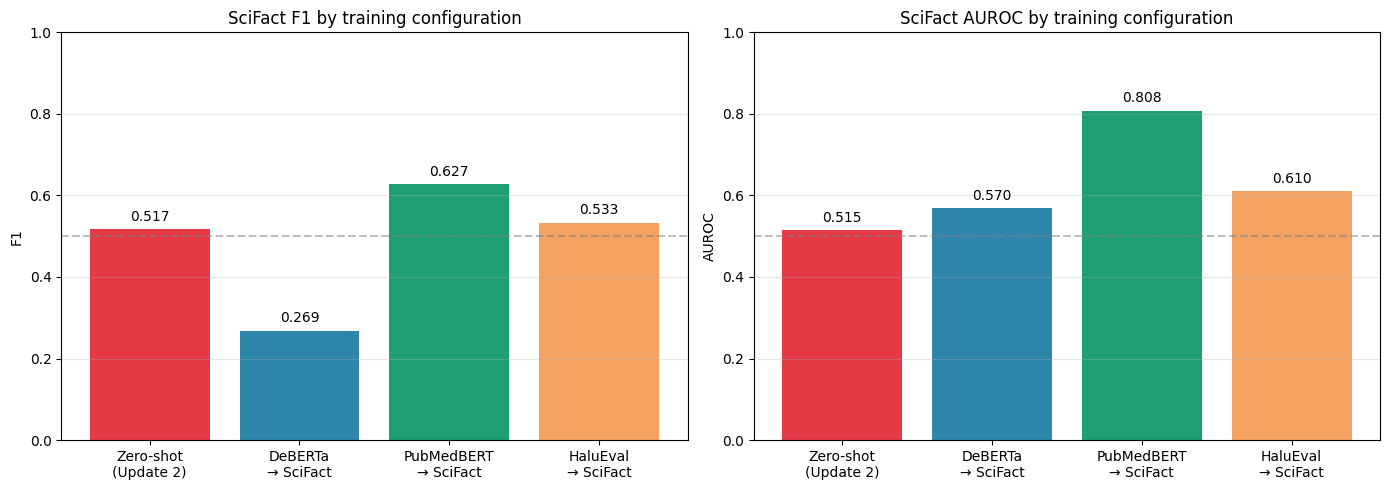

Saved: scifact_domain_specific_comparison.png


In [13]:
# Plot comparison
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

labels_short = ['Zero-shot\n(Update 2)', 'DeBERTa\n→ SciFact', 'PubMedBERT\n→ SciFact', 'HaluEval\n→ SciFact']
f1s = [r['f1'] for r in all_results]
aurocs = [r['auroc'] for r in all_results]
colors = ['#E63946', '#2E86AB', '#1D9E75', '#F4A261']

bars1 = axes[0].bar(labels_short, f1s, color=colors)
axes[0].set_ylabel('F1')
axes[0].set_title('SciFact F1 by training configuration')
axes[0].set_ylim(0, 1.0)
axes[0].axhline(0.5, color='gray', linestyle='--', alpha=0.5, label='Random baseline')
axes[0].grid(axis='y', alpha=0.3)
for bar, val in zip(bars1, f1s):
    axes[0].text(bar.get_x() + bar.get_width()/2, val + 0.02, f'{val:.3f}', ha='center', fontsize=10)

bars2 = axes[1].bar(labels_short, aurocs, color=colors)
axes[1].set_ylabel('AUROC')
axes[1].set_title('SciFact AUROC by training configuration')
axes[1].set_ylim(0, 1.0)
axes[1].axhline(0.5, color='gray', linestyle='--', alpha=0.5, label='Random baseline')
axes[1].grid(axis='y', alpha=0.3)
for bar, val in zip(bars2, aurocs):
    axes[1].text(bar.get_x() + bar.get_width()/2, val + 0.02, f'{val:.3f}', ha='center', fontsize=10)

plt.tight_layout()
plt.savefig("scifact_domain_specific_comparison.png", dpi=150)
plt.show()
print("Saved: scifact_domain_specific_comparison.png")

## 11. Save per-example predictions for error analysis

In [14]:
predictions_df = pd.DataFrame({
    'text': [e['text'][:300] for e in test_examples],
    'true_label': test_labels,
    'zeroshot_prob': baseline_result['test_probs'],
    'zeroshot_pred': baseline_result['test_preds'],
    'deberta_scifact_prob': result_A['test_probs'],
    'deberta_scifact_pred': result_A['test_preds'],
    'pubmedbert_scifact_prob': result_B['test_probs'],
    'pubmedbert_scifact_pred': result_B['test_preds'],
    'halueval_to_scifact_prob': result_C['test_probs'],
    'halueval_to_scifact_pred': result_C['test_preds'],
})
predictions_df.to_csv("scifact_per_example_predictions.csv", index=False)
print("Saved: scifact_per_example_predictions.csv")

Saved: scifact_per_example_predictions.csv
